# RM (Reissner-Mindlin) Timoshenko 6×6 from a 1-D shell YAML

The **Reissner-Mindlin (RM) shell** cross-section model carries an independent through-thickness
*director rotation*, so it retains the **transverse-shear** compliance that the Kirchhoff-Love model
discards. For thin-walled composite sections the payoff is the two shear-stiffness terms
$GA_{2}$ and $GA_{3}$ (rows/cols 2,3 of the $6\times6$).

This tutorial runs the RM solver on the **single-ply $[-45]$ tube** (thesis §3.1.4) directly from its
1-D shell SG YAML, draws the $e_1/e_2/e_3$ material orientation, and benchmarks the result against the
2-D solid reference. The Timoshenko stiffness order is
$[\,EA,\;GA_2,\;GA_3,\;GJ,\;EI_2,\;EI_3\,]$.

> Driver: `strip_RM.rm_timoshenko_6x6(yaml, frac, dshift, curved, shear="mitc")`
> (`shear="mitc"` = selective assumed-strain transverse shear).

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in ("", "opensg_jax"):
    sys.path.insert(0, os.path.join(CC, p))
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=150, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
LBL = ["EA", "GA2", "GA3", "GJ", "EI2", "EI3"]
def sym(M):
    M = np.asarray(M, dtype=float); return 0.5 * (M + M.T)
def pcterr(C, S):
    # all nonzero terms; neglect (->0) any term >=1000x below the max |term| in the reference
    C, S = sym(C), sym(S); thr = np.max(np.abs(S)) / 1000.0; out = np.zeros((6, 6))
    for i in range(6):
        for j in range(6):
            out[i, j] = 100.0 * (C[i, j] - S[i, j]) / S[i, j] if abs(S[i, j]) >= thr else 0.0
    return out
def diag_table(name, C, S):
    C, S = sym(C), sym(S)
    print("  %-5s %15s %15s %12s" % ("term", name, "benchmark", "%err"))
    for i in range(6):
        e = 100.0 * (C[i, i] - S[i, i]) / S[i, i]
        print("  %-5s %15.5e %15.5e %+11.4f" % (LBL[i], C[i, i], S[i, i], e))
print("environment ready  |  jax", jax.__version__)

environment ready  |  jax 0.9.2


In [2]:
SHELL = os.path.join(CC, "examples", "data", "1d_yaml", "tube_m45_shell.yaml")
SOLIDY = os.path.join(CC, "examples", "data", "2d_yaml", "tube_m45_solid.yaml")
BENCH = os.path.join(CC, "examples", "data", "benchmark", "tube_m45_solid_ref.txt")   # 2-D solid reference 6x6
print("shell YAML :", os.path.basename(SHELL))
print("solid YAML :", os.path.basename(SOLIDY))
print("benchmark  :", os.path.basename(BENCH))

shell YAML : tube_m45_shell.yaml
solid YAML : tube_m45_solid.yaml
benchmark  : tube_m45_solid_ref.txt


## Material orientation ($e_1$ beam axis, $e_2$ tangent, $e_3$ wall normal)

$e_2$ (blue) is the in-plane ply-flow direction, $e_3$ (green when OML→IML) is the wall normal, and
$e_1$ is the out-of-plane beam axis ($e_{1z}\approx1$).

[orient_plot] SHELL: e3 OML->IML 200/200   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 464/464   e1_z mean=0.707


[orient_plot] wrote _img/rm_tube_orient.png


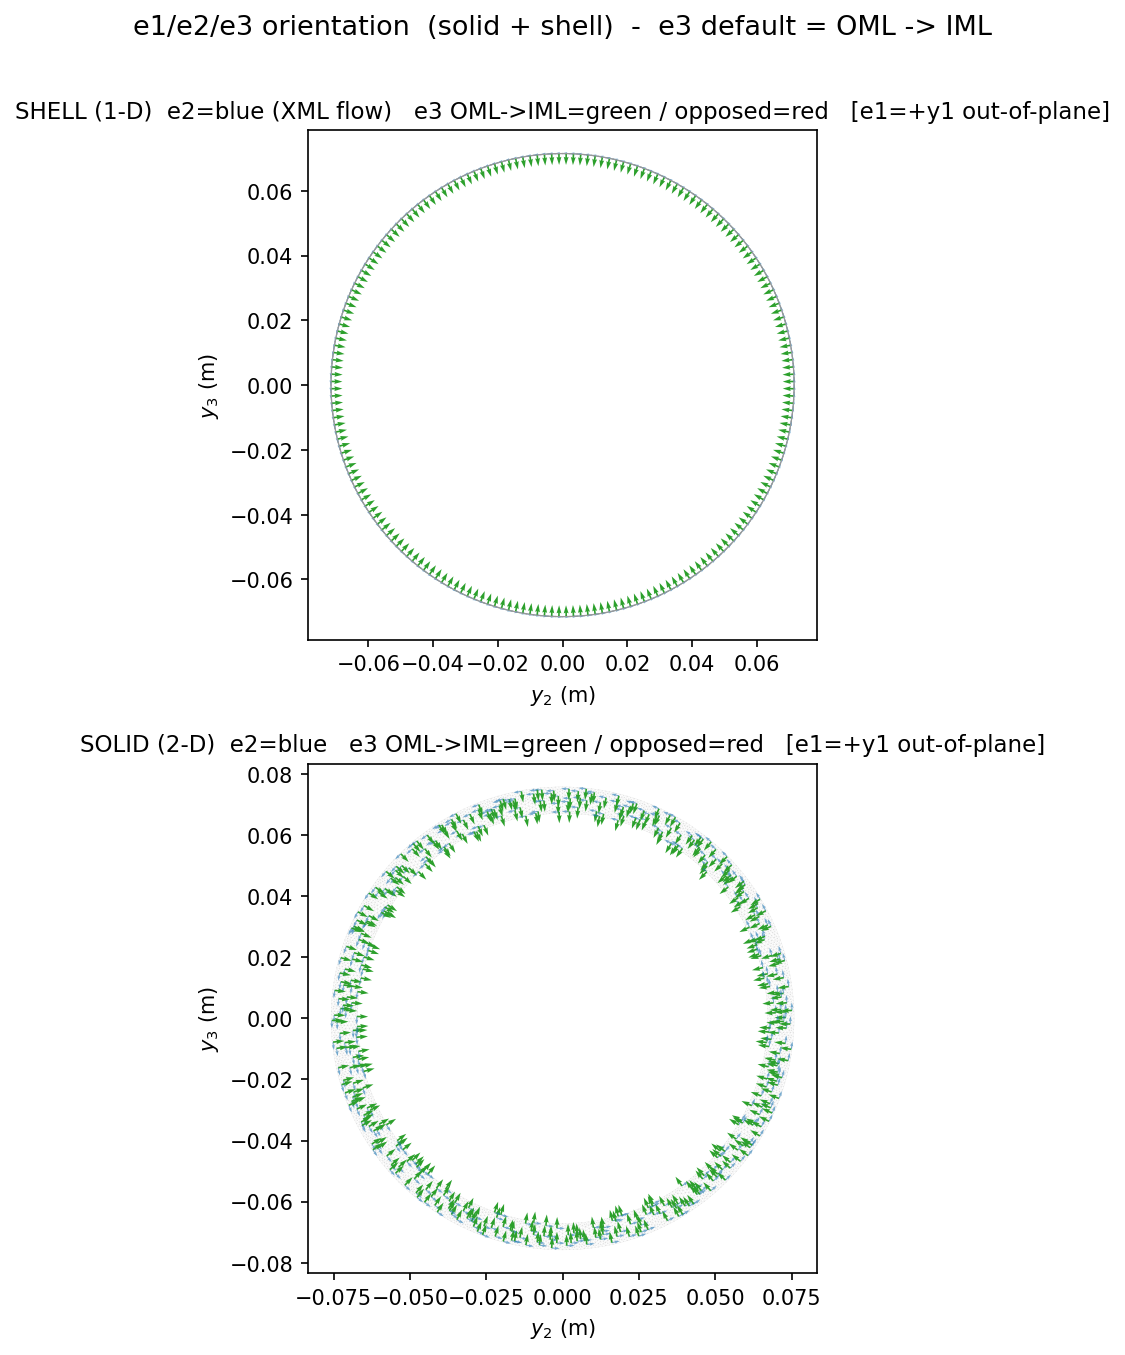

In [3]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(os.path.join(CC, "docs", "tutorials", "_img"), "rm_tube_orient.png"))
Image(filename=png)

## Compute the RM Timoshenko 6×6

In [4]:
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
t0 = time.time()
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=None, curved=True, shear="mitc"))
print("RM solve: %.2f s\n" % (time.time() - t0))
print("RM Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:")
print(C_rm)

[orient_plot] SHELL: e3 OML->IML 200/200   e1_z mean=1.000


[orient_plot] wrote ../../examples/data/1d_yaml/tube_m45_shell_orient_e1e2e3.png


RM solve: 3.15 s

RM Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
[[47727163.5222        0.           -0.      -822254.2231       -0.           -0.    ]
 [       0.     12765019.6053        0.            0.       410964.0669       -0.    ]
 [      -0.            0.     12765019.6053        0.            0.       410964.0669]
 [ -822254.2231        0.            0.       115573.6873        0.           -0.    ]
 [      -0.       410964.0669        0.            0.       107699.363        -0.    ]
 [      -0.           -0.       410964.0669       -0.           -0.       107699.363 ]]


## Benchmark vs the 2-D solid, and vs Kirchhoff-Love

KL severely under-predicts $GA_2,GA_3$; RM recovers them.

In [5]:
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
S = sym(np.loadtxt(BENCH))
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=None)[0])
print("  %-5s %14s %14s %14s %10s %10s" % ("term", "RM", "KL", "solid", "RM %err", "KL %err"))
for i in range(6):
    rm = 100 * (C_rm[i, i] - S[i, i]) / S[i, i]
    kl = 100 * (C_kl[i, i] - S[i, i]) / S[i, i]
    print("  %-5s %14.5e %14.5e %14.5e %+9.2f %+9.2f" % (LBL[i], C_rm[i, i], C_kl[i, i], S[i, i], rm, kl))
print("\nFull 6x6 %-error of RM vs solid:")
print(pcterr(C_rm, S))

  term              RM             KL          solid    RM %err    KL %err
  EA       4.77272e+07    4.77526e+07    4.77381e+07     -0.02     +0.03
  GA2      1.27650e+07    8.13997e+06    1.46606e+07    -12.93    -44.48
  GA3      1.27650e+07    4.59439e+06    1.46606e+07    -12.93    -68.66
  GJ       1.15574e+05    1.15362e+05    1.49334e+05    -22.61    -22.75
  EI2      1.07699e+05    1.02814e+05    1.22532e+05    -12.11    -16.09
  EI3      1.07699e+05    9.93426e+04    1.22532e+05    -12.11    -18.93

Full 6x6 %-error of RM vs solid:
[[ -0.023    0.       0.     -12.4441   0.       0.    ]
 [  0.     -12.9298   0.       0.     -12.7087   0.    ]
 [  0.       0.     -12.9298   0.       0.     -12.7087]
 [-12.4441   0.       0.     -22.6073   0.       0.    ]
 [  0.     -12.7087   0.       0.     -12.1051   0.    ]
 [  0.       0.     -12.7087   0.       0.     -12.1051]]


## Takeaway

On the $[-45]$ tube the **shear terms** separate the models: KL gives $GA_2,GA_3$ errors of
$\sim-44\%/-69\%$, while **RM** brings them to $\sim-13\%$. Classical terms already agree to under 1%.
For the full 2-D solid reference (matched to VABS) see the **JAX-solid** tutorial.